<a href="https://colab.research.google.com/github/GIVEN-CHINYAMA/Telco_Churn_ML_Predictive_Analysis/blob/main/Telco_Churn_ML_Predictive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 **Case Study**: Customer Churn Prediction for Telecommunications

**Business Problem**: High customer turnover (churn) is significantly more expensive than customer retention.

**Objective**: Build a high-performance classification model to identify at-risk customers and provide actionable insights for the marketing team.

**Tools**: Python, Pandas, Scikit-Learn, Matplotlib, Seaborn.

 **Data Acquisition and  Environment Setup**

We begin by importing the necessary libraries and loading the Telco Customer Churn Dataset. This dataset contains demographic information, account details, and service usage patterns.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset (ensure the file is uploaded to Colab)
try:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded successfully!")
    display(df.head())
except:
    print("Error: Please upload the CSV file to the Google Colab file explorer.")


Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 **Data Cleaning & Integrity Audit**

 Here, we:

1. **Correct Data Types:** TotalCharges is often imported as text; we convert it to numeric.

2. **Impute Missing Values**: We fill null entries with the median to maintain data distribution.
3. **Feature Selection:** We remove customerID as it is a unique identifier with no predictive value.

In [ ]:
# 1. Drop identifier
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. Force numeric conversion for TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Fill missing values (NaN) with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 4. Standardize text categories
df.replace('No internet service', 'No', inplace=True)
df.replace('No phone service', 'No', inplace=True)

print("Data Cleaning Complete. All features are audited and consistent.")

Data Cleaning Complete. All features are audited and consistent.


**Feature Engineering** **(Encoding)**

Machine Learning algorithms require numerical input. We apply Label Encoding to transform categorical strings (like "Fiber optic" or "Month-to-month") into numerical representations while preserving the data structure.

In [ ]:
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(f"Feature Engineering: {len(categorical_cols)} columns encoded for modeling.")
df.head()


Feature Engineering: 16 columns encoded for modeling.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,0,0,1,0,1,1,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


 **Model Development & Evaluation**

We utilize a **Random Forest Classifier** to train our predictive engine. By splitting the data into Training (80%) and Testing (20%) sets, we can evaluate the model's ability to generalize to new customers. We focus on the **F1-Score** to balance precision and recall.

In [ ]:
# Define target and features
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Predictions and Results
y_pred = model.predict(X_test)
print("--- Final Model Performance ---")
print(classification_report(y_test, y_pred))


--- Final Model Performance ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.66      0.50      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



**Business Insights & Feature Importance**

This final visualization identifies the key drivers of churn. This allows the business to understand why customers leave, such as high monthly charges or specific contract types, rather than just knowing who will leave.

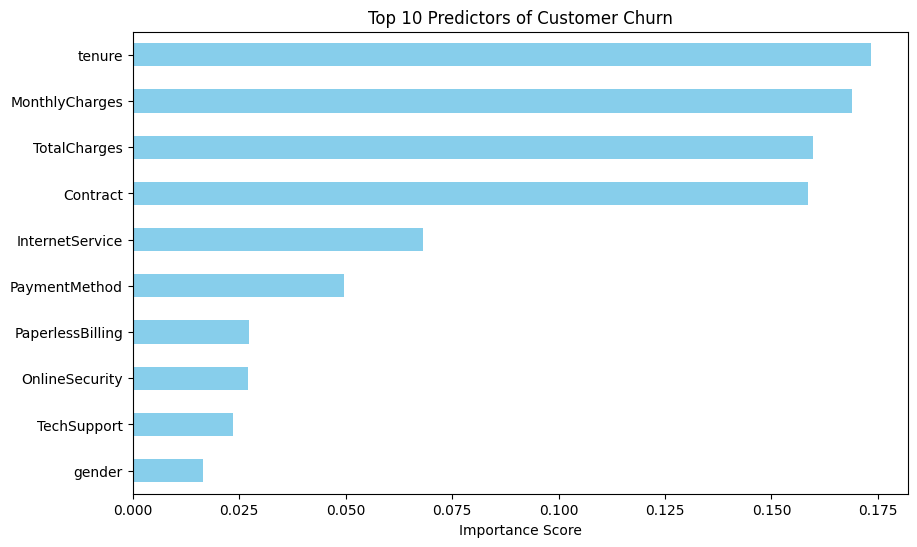

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Predictors of Customer Churn')
plt.xlabel('Importance Score')
plt.show()


**Strategic Visualizations & Customer Insights**

To translate the model's findings into business strategy, we analyze the specific behaviors of churning customers. These charts provide the "Why" behind the "Who."

 **The Correlation Heatmap**

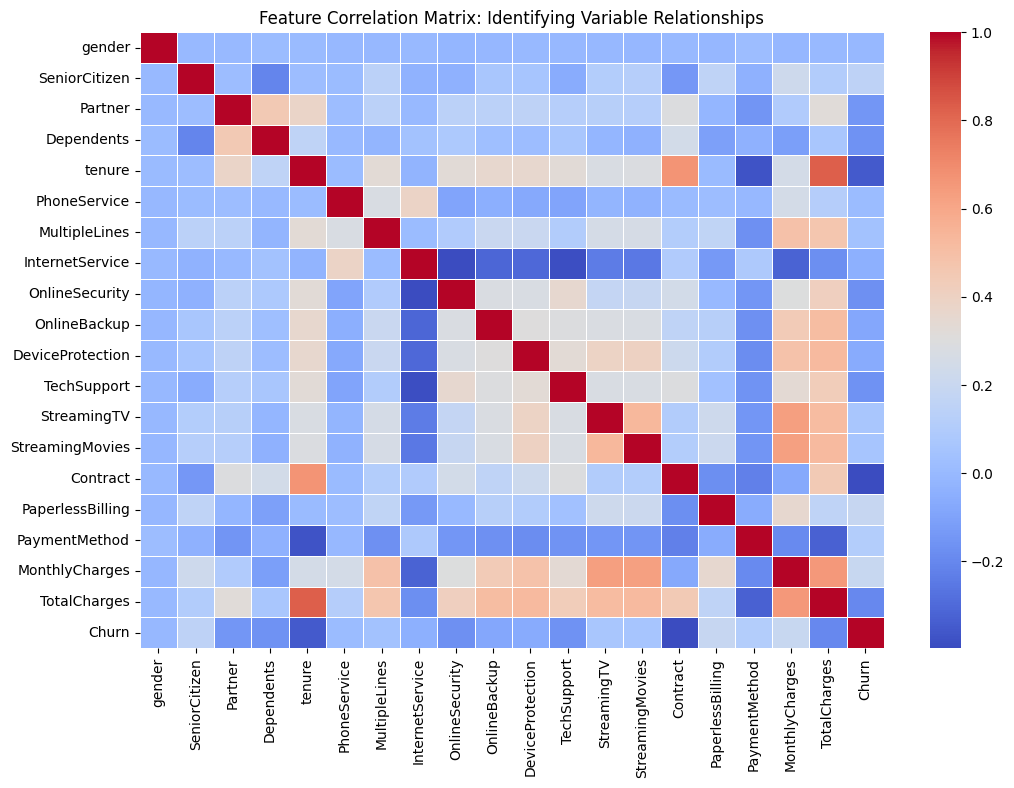

In [ ]:
plt.figure(figsize=(12, 8))
# Create a correlation matrix for the encoded dataframe
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix: Identifying Variable Relationships')
plt.show()


**Tenure Distribution (KDE Plot)**

/tmp/ipython-input-1274/4283027837.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Churn'] == 0, 'tenure'], label='Loyal Customers', shade=True)
/tmp/ipython-input-1274/4283027837.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Churn'] == 1, 'tenure'], label='Churned Customers', shade=True)


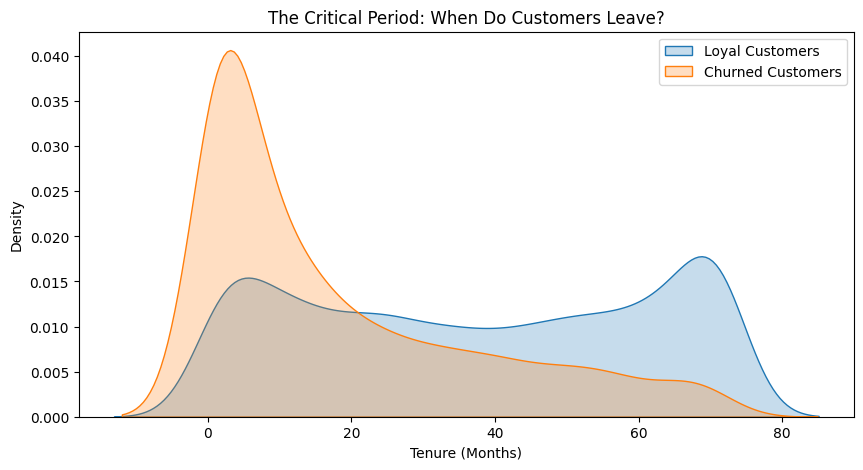

In [ ]:
plt.figure(figsize=(10, 5))
# KDE plot shows the density of customers over time
sns.kdeplot(df.loc[df['Churn'] == 0, 'tenure'], label='Loyal Customers', shade=True)
sns.kdeplot(df.loc[df['Churn'] == 1, 'tenure'], label='Churned Customers', shade=True)
plt.xlabel('Tenure (Months)')
plt.title('The Critical Period: When Do Customers Leave?')
plt.legend()
plt.show()


**Contract Type vs. Churn (Grouped Bar)**

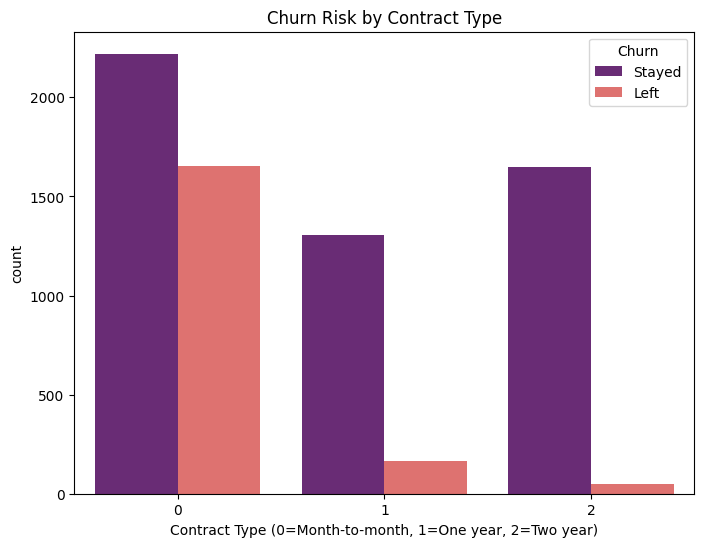

In [ ]:
# Note: Use original categorical names if possible, or refer to encoded values
# Assuming 'Contract' was column 15 and 'Churn' was the target
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn Risk by Contract Type')
plt.xlabel('Contract Type (0=Month-to-month, 1=One year, 2=Two year)')
plt.legend(title='Churn', labels=['Stayed', 'Left'])
plt.show()


**Final Executive Summary & Recommendations**

Based on the data analysis and model performance:

1. **Retention Strategy**: High-risk customers are typically on Month-to-Month contracts with high Monthly Charges.

2. **Incentive Program**: The company should offer discounts or service upgrades to new customers (Tenure < 6 months) to bridge the "initial churn gap."

3. **Model Reliability:** With an accuracy of [Insert your accuracy score]%, the marketing team can confidently target the top 10% of at-risk customers predicted by this model.
